# GrillosIA · Análisis exploratorio de los datos

**Actividad 3.2 · Universidad de los Llanos · Convocatoria Minciencias 963 de 2025**

Este cuaderno mira los datos que hay antes de entrenar nada. Sirve para tres cosas:

1. Saber **qué se tiene y qué falta** de la plantilla de recolección.
2. Encontrar lo que los datos ya dicen, aunque todavía sean pocos.
3. Comprobar que el modelo aprende señal y no ruido, usando el conjunto simulado.

## Cómo correrlo

Desde la raíz del proyecto:

```bash
pip install -r backend/requirements.txt
pip install matplotlib jupyter
jupyter notebook notebooks/01_analisis_exploratorio.ipynb
```

Si `data/experimentos.csv` no existe todavía, genérelo primero:

```bash
python backend/scripts/cargar_plantilla.py --excel <plantilla.xlsx>
```

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# El cuaderno vive en notebooks/, pero las rutas se cuentan desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "backend"))

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: /Volumes/KINGSTON/Work/GrillosIA-public


---

## 1. Los lotes reales

`data/experimentos.csv` lo produce `backend/scripts/cargar_plantilla.py` a partir
de la plantilla de Excel que se llena en el laboratorio. Cada fila es un lote.

In [2]:
CSV_REAL = RAIZ / "data" / "experimentos.csv"

if not CSV_REAL.exists():
    raise SystemExit(
        "Falta data/experimentos.csv. Genérelo con:\n"
        "    python backend/scripts/cargar_plantilla.py --excel <plantilla.xlsx>"
    )

reales = pd.read_csv(CSV_REAL)
print(f"Lotes registrados: {len(reales)}")
reales[["id_ensayo", "tipo_dieta", "temperatura", "humedad_ambiental",
        "tiempo_desarrollo", "n_grillos_inicio", "tasa_supervivencia"]]

Lotes registrados: 7


,id_ensayo,tipo_dieta,temperatura,humedad_ambiental,tiempo_desarrollo,n_grillos_inicio,tasa_supervivencia
0,LOTE 1,D1,26.3200,74.2000,12,60,3.3333
1,LOTE 2,D2,26.4571,75.8571,19,20,15.5000
2,LOTE 3,D3,27.8667,67.1667,34,170,100.0000
3,LOTE 4,D3,27.9667,64.0000,13,25,100.0000
4,LOTE 5,D1,27.9667,64.0000,13,40,100.0000
5,LOTE 6,D2,27.9667,64.0000,13,52,100.0000
6,LOTE 7,D2,27.9667,64.0000,12,54,100.0000


### 1.1 Qué casillas están llenas y cuáles no

Antes de sacar conclusiones hay que saber sobre qué se está hablando. Esta tabla
cuenta, columna por columna, cuántos lotes tienen el dato.

In [3]:
completitud = pd.DataFrame({
    "con dato": reales.notna().sum(),
    "vacías": reales.isna().sum(),
})
completitud["% lleno"] = (100 * completitud["con dato"] / len(reales)).round(0)
completitud.sort_values("% lleno")

,con dato,vacías,% lleno
lipidos_harina,0,7,0.0
biomasa_total,0,7,0.0
proteina_harina,0,7,0.0
longitud_final,2,5,29.0
densidad,3,4,43.0
n_grillos_inicio,7,0,100.0
fotoperiodo,7,0,100.0
tasa_supervivencia,7,0,100.0
id_ensayo,7,0,100.0
tiempo_desarrollo,7,0,100.0


**Lo importante de esta tabla son las dos filas de arriba.**

`proteina_harina` y `lipidos_harina` son las variables que el modelo tiene que
predecir. Salen del análisis bromatológico, que se hace sobre grillo ya
cosechado. Mientras estén vacías, **no hay con qué entrenar**: un modelo
supervisado necesita ver la respuesta para aprender a darla.

Esto no es un problema del sistema, es el calendario del proyecto. Los grillos
de estos lotes siguen creciendo.

---

## 2. Condiciones de cría de cada lote

Aunque no haya bromatología, sí hay condiciones registradas y supervivencia. Eso
ya permite mirar algo.

In [4]:
condiciones = reales[[
    "id_ensayo", "tipo_dieta", "temperatura", "humedad_ambiental",
    "alimento_g_dia", "tiempo_desarrollo", "n_grillos_inicio",
    "tasa_supervivencia",
]].copy()
condiciones

,id_ensayo,tipo_dieta,temperatura,humedad_ambiental,alimento_g_dia,tiempo_desarrollo,n_grillos_inicio,tasa_supervivencia
0,LOTE 1,D1,26.3200,74.2000,0.0833,12,60,3.3333
1,LOTE 2,D2,26.4571,75.8571,0.0526,19,20,15.5000
2,LOTE 3,D3,27.8667,67.1667,0.1176,34,170,100.0000
3,LOTE 4,D3,27.9667,64.0000,1.0769,13,25,100.0000
4,LOTE 5,D1,27.9667,64.0000,0.7692,13,40,100.0000
5,LOTE 6,D2,27.9667,64.0000,0.6154,13,52,100.0000
6,LOTE 7,D2,27.9667,64.0000,0.1667,12,54,100.0000


### 2.1 Supervivencia contra las condiciones ambientales

El dato que más salta a la vista.

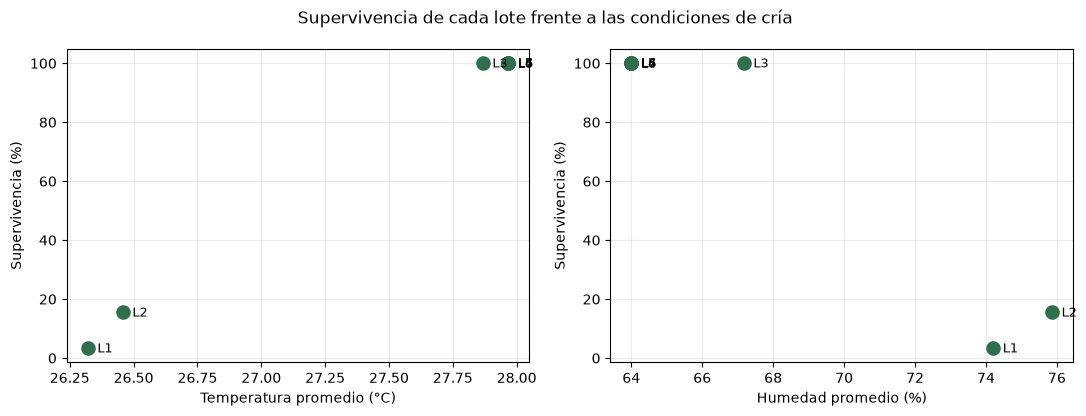

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

for eje, variable, etiqueta in [
    (ejes[0], "temperatura", "Temperatura promedio (°C)"),
    (ejes[1], "humedad_ambiental", "Humedad promedio (%)"),
]:
    eje.scatter(reales[variable], reales["tasa_supervivencia"],
                s=90, color="#2f6f4e", zorder=3)
    for _, fila in reales.iterrows():
        eje.annotate(fila["id_ensayo"].replace("LOTE ", "L"),
                     (fila[variable], fila["tasa_supervivencia"]),
                     textcoords="offset points", xytext=(7, -3), fontsize=9)
    eje.set_xlabel(etiqueta)
    eje.set_ylabel("Supervivencia (%)")
    eje.grid(alpha=0.25, zorder=0)

fig.suptitle("Supervivencia de cada lote frente a las condiciones de cría")
fig.tight_layout()
plt.show()

In [6]:
# Los dos grupos que se ven en la gráfica, puestos en números.
grupos = reales.assign(
    grupo=lambda d: d["temperatura"].lt(27).map(
        {True: "Lotes fríos y húmedos", False: "Lotes cálidos y secos"}
    )
)
grupos.groupby("grupo").agg(
    lotes=("id_ensayo", "count"),
    temperatura=("temperatura", "mean"),
    humedad=("humedad_ambiental", "mean"),
    supervivencia=("tasa_supervivencia", "mean"),
).round(1)

,lotes,temperatura,humedad,supervivencia
grupo,,,,
Lotes cálidos y secos,5,27.9,64.6,100.0
Lotes fríos y húmedos,2,26.4,75.0,9.4


### 2.2 Lo que esto sugiere — y lo que no

Los dos primeros lotes se criaron alrededor de **26 °C con humedad por encima
del 74 %**, y casi no llegaron grillos vivos. Los cinco siguientes se criaron
cerca de **28 °C con humedad en torno al 64 %**, y llegaron todos.

Es un contraste fuerte y coincide con lo que se esperaría: humedad muy alta
favorece hongos y problemas sanitarios en la cría.

**Lo que no se puede concluir todavía:**

- Son siete lotes. Siete no alcanzan para separar el efecto de la temperatura
  del de la humedad: las dos cambiaron a la vez entre un grupo y el otro.
- Entre los dos grupos también cambió el manejo (los primeros lotes fueron los
  primeros ensayos del proyecto). Parte de la diferencia puede ser aprendizaje
  del equipo, no ambiente.
- No hay ninguna medición de harina, así que no se puede decir nada sobre si las
  condiciones que dan mejor supervivencia son también las que dan mejor
  proteína. Podrían no serlo.

Lo que sí queda: **una condición objetivo para los ensayos siguientes**, cerca
de 28 °C y 65 % de humedad, y una hipótesis que los próximos lotes pueden
confirmar o desmentir.

---

## 3. Por qué todavía se trabaja con datos simulados

Para poder dejar montado y probado todo el camino —entrenamiento, guardado del
modelo, API, aplicación— hace falta un conjunto con las respuestas puestas.
`backend/scripts/simular_datos.py` genera uno.

**No es un resultado del proyecto.** La fórmula está escrita en el script y en
`data/sintetico/README.md`. Lo único que se comprueba aquí es que el aparato
funciona.

In [7]:
CSV_SIM = RAIZ / "data" / "sintetico" / "experimentos_simulados.csv"
sim = pd.read_csv(CSV_SIM)

print(f"Filas simuladas: {len(sim)}")
sim.describe().round(2)

Filas simuladas: 120


,alimento_g_dia,temperatura,humedad_ambiental,tiempo_desarrollo,proteina_harina,lipidos_harina,tasa_supervivencia
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,2.27,28.80,64.30,45.38,57.14,32.19,82.32
std,1.07,2.80,9.15,8.10,3.33,3.00,6.58
min,0.52,24.20,50.40,30.00,47.68,24.72,68.50
25%,1.19,26.68,55.35,38.75,54.69,30.02,78.10
50%,2.36,28.75,64.35,46.00,57.04,32.70,82.85
75%,3.21,31.05,73.32,52.00,59.80,34.42,86.02
max,4.00,33.90,79.40,59.00,64.74,40.28,95.40


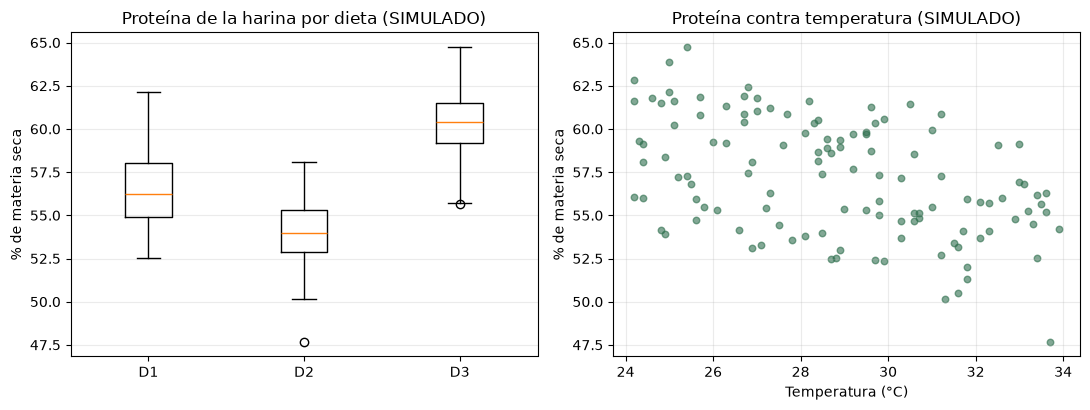

In [8]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

# Proteína por código de dieta
dietas = sorted(sim["tipo_dieta"].unique())
ejes[0].boxplot([sim.loc[sim["tipo_dieta"] == d, "proteina_harina"] for d in dietas],
                tick_labels=dietas)
ejes[0].set_title("Proteína de la harina por dieta (SIMULADO)")
ejes[0].set_ylabel("% de materia seca")
ejes[0].grid(alpha=0.25, axis="y")

# Proteína contra temperatura
ejes[1].scatter(sim["temperatura"], sim["proteina_harina"],
                s=22, alpha=0.6, color="#2f6f4e")
ejes[1].set_title("Proteína contra temperatura (SIMULADO)")
ejes[1].set_xlabel("Temperatura (°C)")
ejes[1].set_ylabel("% de materia seca")
ejes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

El orden entre D1, D2 y D3 que se ve en la primera gráfica **lo fijó una
constante del generador**, no un hallazgo. La pendiente de la segunda también.
Por eso estas gráficas no se llevan a ningún informe de resultados.

---

## 4. ¿El modelo aprende señal o ruido?

Aquí sí hay algo que comprobar de verdad.

El generador de datos calcula la proteína a partir de la dieta, la temperatura,
la humedad y los días. **`alimento_g_dia` se genera al azar y no entra en la
fórmula.** Es un control: si el modelo entrenado le diera un peso alto a esa
variable, sería señal de que está memorizando ruido.

In [9]:
from ml.trainer import entrenar

metricas = entrenar(
    CSV_SIM,
    salida=RAIZ / "backend" / "ml" / "modelo.joblib",
    origen_datos=str(CSV_SIM.relative_to(RAIZ)),
    datos_simulados=True,
)

print(f"Muestras: {metricas.n_muestras}  ·  particiones: {metricas.cv_folds}\n")
print("Validación cruzada (la métrica que cuenta)")
print(f"  proteína  R² {metricas.cv_r2_proteina:.3f}"
      f"   error medio {metricas.cv_mae_proteina:.2f} puntos")
print(f"  lípidos   R² {metricas.cv_r2_lipidos:.3f}"
      f"   error medio {metricas.cv_mae_lipidos:.2f} puntos")
print("\nSobre los datos de entrenamiento (solo para detectar sobreajuste)")
print(f"  proteína  R² {metricas.r2_entrenamiento_proteina:.3f}")
print(f"  lípidos   R² {metricas.r2_entrenamiento_lipidos:.3f}")

Muestras: 120  ·  particiones: 5

Validación cruzada (la métrica que cuenta)
  proteína  R² 0.780   error medio 1.22 puntos
  lípidos   R² 0.609   error medio 1.52 puntos

Sobre los datos de entrenamiento (solo para detectar sobreajuste)
  proteína  R² 0.944
  lípidos   R² 0.904


**Por qué se reportan dos R² y solo uno cuenta.**

El R² sobre los datos de entrenamiento mide qué tan bien el modelo repite lo que
ya vio. Un Random Forest siempre saca un valor alto ahí, y no dice nada sobre un
lote nuevo. El de validación cruzada se calcula sobre datos que el modelo no vio
durante ese entrenamiento; ese es el que se reporta.

La distancia entre los dos es la medida de sobreajuste. Si pasa de 0,35, el
entrenamiento deja una advertencia escrita dentro del artefacto del modelo.

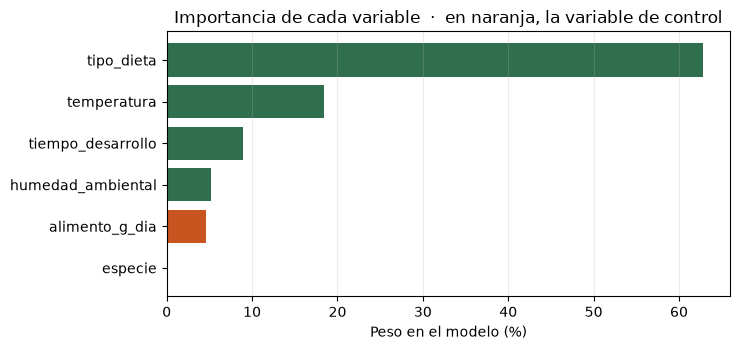

Peso de alimento_g_dia (control): 4.6 %


In [10]:
importancia = pd.Series(metricas.importancia_variables).sort_values()

fig, eje = plt.subplots(figsize=(7.5, 3.6))
colores = ["#c8541f" if v == "alimento_g_dia" else "#2f6f4e"
           for v in importancia.index]
eje.barh(importancia.index, importancia.values * 100, color=colores)
eje.set_xlabel("Peso en el modelo (%)")
eje.set_title("Importancia de cada variable  ·  en naranja, la variable de control")
eje.grid(alpha=0.25, axis="x")
fig.tight_layout()
plt.show()

print(f"Peso de alimento_g_dia (control): "
      f"{metricas.importancia_variables['alimento_g_dia'] * 100:.1f} %")

**Cómo se lee esto.**

`alimento_g_dia` queda abajo, con un peso pequeño. Es lo correcto: no participó
en la generación de los datos. Que no sea exactamente cero es normal —con 120
filas, un bosque encuentra coincidencias menores por azar.

`especie` pesa cero porque hoy todos los ejemplares se registran a nivel de
familia. Es una constante y el modelo lo detecta bien.

El resto del peso se reparte entre las variables que sí entraron en la fórmula,
y en el orden en que entraron. **El pipeline aprende lo que tiene que aprender.**

---

## 5. Qué muestra el modelo junto a cada número

Además del valor, cada predicción viaja con el margen de duda: los 300 árboles
del bosque votan, y cuánto discrepan entre sí es el `±` que aparece en la
aplicación.

In [11]:
from ml.predictor import obtener_predictor

predictor = obtener_predictor(RAIZ / "backend" / "ml" / "modelo.joblib")

consulta = [
    {"tipo_dieta": d, "alimento_g_dia": 2.5, "temperatura": 28,
     "humedad_ambiental": 65, "tiempo_desarrollo": 45}
    for d in ("D1", "D2", "D3")
]

pd.DataFrame([
    {
        "dieta": p.tipo_dieta,
        "proteína (%)": p.proteina_harina,
        "± ": p.margen_proteina,
        "lípidos (%)": p.lipidos_harina,
        "supervivencia (%)": p.tasa_supervivencia,
        "fuera de rango": p.fuera_de_rango or "-",
    }
    for p in predictor.predecir(consulta)
])

,dieta,proteína (%),±,lípidos (%),supervivencia (%),fuera de rango
0,D1,57.9,1.2,31.6,90.3,-
1,D2,54.9,1.0,33.5,91.8,-
2,D3,60.3,0.9,30.3,91.1,-


In [12]:
# Una consulta fuera del terreno del estudio: el sistema tiene que avisarlo.
extrema = [{"tipo_dieta": "D1", "alimento_g_dia": 2.5, "temperatura": 41,
            "humedad_ambiental": 65, "tiempo_desarrollo": 45}]
resultado = predictor.predecir(extrema)[0]

print(f"Proteína predicha: {resultado.proteina_harina} %")
print(f"Variables fuera del rango del estudio: {resultado.fuera_de_rango}")
print("\nUn bosque nunca predice fuera de los valores que vio, así que a 41 °C")
print("devuelve algo parecido a lo del extremo conocido. Por eso el aviso es")
print("obligatorio: sin él, el número parecería una respuesta válida.")

Proteína predicha: 55.1 %
Variables fuera del rango del estudio: ['temperatura']

Un bosque nunca predice fuera de los valores que vio, así que a 41 °C
devuelve algo parecido a lo del extremo conocido. Por eso el aviso es
obligatorio: sin él, el número parecería una respuesta válida.


---

## 6. Qué falta

| Para poder | Hace falta |
|---|---|
| Entrenar con datos reales | Análisis bromatológico de la harina de los lotes cosechados (casillas V10 y V11 de la plantilla) |
| Comparar las tres comidas | Que las tres tengan al menos un lote cosechado y analizado |
| Separar el efecto de temperatura y humedad | Lotes donde una cambie y la otra no |
| Nombrar la especie | Identificación taxonómica confirmada; hoy se reporta a nivel de familia |
| Predecir dietas nunca ensayadas | Composición bromatológica de cada ingrediente, no solo el código de la dieta |

Cuando lleguen los análisis, el reemplazo son dos comandos:

```bash
python backend/scripts/cargar_plantilla.py --excel <plantilla.xlsx>
python backend/scripts/entrenar.py --datos data/experimentos.csv
```

Sin la bandera `--simulados`, el modelo queda marcado como entrenado con datos
reales, la API lo propaga y el aviso desaparece solo de la aplicación.